# 01 — EDA del dataset de video (UCF-Crime / VioPeru)

Análisis exploratorio previo al entrenamiento:

1. Distribución de clases (desbalance)
2. **Duración**: mínimo, máximo, media, mediana y **moda**
3. **Resolución moda**, orientación, relación de aspecto; **FPS moda**; tamaño de archivo
4. **Videos monocromáticos** (B/N, IR nocturno)
5. **Brillo**: videos oscuros y muy brillantes; contraste y nitidez
6. Inspección visual de muestras
7. Videos corruptos
8. Conclusiones

**Entrada**: `data/raw/<Clase>/<video>.mp4` (o carpetas de frames `<Clase>/<video>/*.jpg`).
**Salidas**: `artifacts/eda/` (CSV por video, resumen JSON, figuras y listas).

## 0. Configuración

In [1]:
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Carpeta con los videos (una subcarpeta por clase). Se usa la primera que exista.
CANDIDATOS = [ROOT / "data" / "raw", ROOT / "ucf_crime", ROOT / "data"]
DATA_DIR = next((p for p in CANDIDATOS if p.exists()), CANDIDATOS[0])
OUT_DIR = ROOT / "artifacts" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_FRAMES = 16        # frames muestreados por video para brillo/color
WORKERS = 8          # hilos de lectura
LIMIT = None         # p.ej. 50 para una prueba rápida
FPS_FRAMES = 30.0    # FPS asumido si el dataset está como carpetas de frames (UCF-Crime = 30 fps)

# Umbrales
DARK_THR = 30.0          # brillo medio < 30 -> oscuro (mismo umbral del filtro de calidad)
BRIGHT_THR = 200.0       # brillo medio > 200 -> muy brillante / sobreexpuesto
MONO_SAT_THR = 12.0      # saturación media HSV < 12 -> monocromático
MONO_CHAN_THR = 4.0      # diferencia media entre canales RGB < 4 -> monocromático
BLUR_THR = 50.0          # varianza del Laplaciano < 50 -> borroso
LOW_CONTRAST_THR = 20.0  # desv. estándar de luma < 20 -> bajo contraste

VIDEO_EXT = {".mp4", ".avi", ".mkv", ".mov", ".webm", ".mpg", ".mpeg", ".wmv", ".flv"}
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 50)
print("DATA_DIR:", DATA_DIR, "| existe:", DATA_DIR.exists())
print("OUT_DIR :", OUT_DIR)

DATA_DIR: e:\deepl\MIA\data\raw | existe: True
OUT_DIR : e:\deepl\MIA\artifacts\eda


## 1. Funciones de extracción

Por cada video se leen los metadatos (FPS, nº frames, resolución, códec) y se muestrean `N_FRAMES` frames uniformes para medir brillo (luma Y), contraste, saturación, diferencia entre canales RGB, píxeles quemados/negros y nitidez.

In [2]:
def frame_stats(fr):
    gray = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(fr, cv2.COLOR_BGR2HSV)
    f = fr.astype(np.int16)
    chan_diff = (np.abs(f[..., 0] - f[..., 1]) + np.abs(f[..., 1] - f[..., 2]) + np.abs(f[..., 0] - f[..., 2])) / 3
    lit = hsv[..., 2] > 30   # la saturación HSV es inestable en píxeles casi negros
    return dict(
        brightness=gray.mean(), contrast=gray.std(),
        saturation=hsv[..., 1][lit].mean() if lit.any() else 0.0,
        chan_diff=chan_diff.mean(),
        pct_white=(gray >= 250).mean() * 100, pct_black=(gray <= 5).mean() * 100,
        sharpness=cv2.Laplacian(gray, cv2.CV_64F).var(),
    )


def _resize(fr, w=320):
    return cv2.resize(fr, (w, int(fr.shape[0] * w / fr.shape[1]))) if fr.shape[1] > w else fr


def analizar_video(path):
    p = Path(path)
    row = dict(path=str(p), video=p.name, clase=p.parent.name, tipo="video",
               size_mb=round(p.stat().st_size / 1e6, 3), corrupt=False)
    cap = cv2.VideoCapture(str(p))
    if not cap.isOpened():
        row["corrupt"] = True
        return row
    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cc = int(cap.get(cv2.CAP_PROP_FOURCC))
    row.update(fps=round(fps, 2), n_frames=n, width=w, height=h, codec="".join(chr((cc >> 8 * i) & 0xFF) for i in range(4)).strip())
    row["duration_s"] = n / fps if fps > 0 else np.nan
    stats = []
    for i in np.unique(np.linspace(0, max(n - 1, 0), num=min(N_FRAMES, max(n, 1)), dtype=int)):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, fr = cap.read()
        if ok and fr is not None:
            stats.append(frame_stats(_resize(fr)))
    cap.release()
    if not stats:
        row["corrupt"] = True
        return row
    row.update(pd.DataFrame(stats).mean().to_dict())
    return row


def analizar_carpeta_frames(path):
    p = Path(path)
    imgs = sorted(f for f in p.iterdir() if f.suffix.lower() in IMG_EXT)
    row = dict(path=str(p), video=p.name, clase=p.parent.name, tipo="frames",
               size_mb=round(sum(f.stat().st_size for f in imgs) / 1e6, 3), corrupt=False,
               fps=FPS_FRAMES, n_frames=len(imgs), codec="jpg")
    if not imgs:
        row["corrupt"] = True
        return row
    first = cv2.imread(str(imgs[0]))
    if first is None:
        row["corrupt"] = True
        return row
    row.update(width=first.shape[1], height=first.shape[0], duration_s=len(imgs) / FPS_FRAMES)
    idx = np.unique(np.linspace(0, len(imgs) - 1, num=min(N_FRAMES, len(imgs)), dtype=int))
    stats = [frame_stats(_resize(fr)) for fr in (cv2.imread(str(imgs[i])) for i in idx) if fr is not None]
    row.update(pd.DataFrame(stats).mean().to_dict())
    return row


def listar_items(data_dir):
    videos = sorted(p for p in data_dir.rglob("*") if p.suffix.lower() in VIDEO_EXT)
    if videos:
        return videos, analizar_video
    carpetas = sorted({f.parent for f in data_dir.rglob("*") if f.suffix.lower() in IMG_EXT})
    return carpetas, analizar_carpeta_frames

## 2. Extracción (puede tardar varios minutos con el dataset completo)

In [3]:
items, fn = listar_items(DATA_DIR)
if LIMIT:
    items = items[:LIMIT]
assert items, f"No se encontraron videos ni frames en {DATA_DIR}"
print(f"{len(items)} elementos ({fn.__name__})")

rows = []
with ThreadPoolExecutor(max_workers=WORKERS) as ex:
    futs = {ex.submit(fn, str(it)): it for it in items}
    for k, fu in enumerate(as_completed(futs), 1):
        try:
            rows.append(fu.result())
        except Exception as e:
            it = futs[fu]
            rows.append(dict(path=str(it), video=it.name, clase=it.parent.name, corrupt=True, error=str(e)))
        if k % 200 == 0 or k == len(items):
            print(f"  {k}/{len(items)}")

df = pd.DataFrame(rows).sort_values(["clase", "video"]).reset_index(drop=True)
ok = ~df["corrupt"]
df["resolution"] = df["width"].astype("Int64").astype(str) + "x" + df["height"].astype("Int64").astype(str)
df["aspect_ratio"] = (df["width"] / df["height"]).round(3)
df["orientation"] = np.select([df.width > df.height, df.height > df.width], ["horizontal", "vertical"], "cuadrado")

df["is_dark"] = ok & (df["brightness"] < DARK_THR)
df["is_bright"] = ok & (df["brightness"] > BRIGHT_THR)
df["is_monochrome"] = ok & ((df["saturation"] < MONO_SAT_THR) | (df["chan_diff"] < MONO_CHAN_THR))
df["is_blurry"] = ok & (df["sharpness"] < BLUR_THR)
df["is_low_contrast"] = ok & (df["contrast"] < LOW_CONTRAST_THR)
df["brightness_cat"] = pd.cut(df["brightness"], [-1, DARK_THR, 85, 170, BRIGHT_THR, 256],
                              labels=["muy oscuro", "oscuro", "normal", "claro", "muy brillante"])

df.to_csv(OUT_DIR / "video_metadata.csv", index=False)
v = df[ok].copy()
df.head()

1900 elementos (analizar_video)
  200/1900
  400/1900
  600/1900
  800/1900
  1000/1900
  1200/1900
  1400/1900
  1600/1900
  1800/1900
  1900/1900


,path,video,clase,tipo,size_mb,corrupt,fps,n_frames,width,height,codec,duration_s,brightness,contrast,saturation,chan_diff,pct_white,pct_black,sharpness,resolution,aspect_ratio,orientation,is_dark,is_bright,is_monochrome,is_blurry,is_low_contrast,brightness_cat
0,e:\deepl\MIA\data\raw\ucf_crime_videos\Anomaly...,Abuse001_x264.mp4,Abuse,video,21.495,False,30.0,2729,320,240,h264,90.966667,67.912974,68.465467,56.982845,9.393725,0.437663,37.918701,1029.800412,320x240,1.333,horizontal,False,False,False,False,False,oscuro
1,e:\deepl\MIA\data\raw\ucf_crime_videos\Anomaly...,Abuse002_x264.mp4,Abuse,video,7.254,False,30.0,865,320,240,h264,28.833333,97.368434,50.842456,27.696696,6.844134,0.340739,0.210286,1552.856251,320x240,1.333,horizontal,False,False,False,False,False,normal
2,e:\deepl\MIA\data\raw\ucf_crime_videos\Anomaly...,Abuse003_x264.mp4,Abuse,video,25.940,False,30.0,3699,320,240,h264,123.300000,96.333057,68.699909,25.752271,6.590203,0.703206,25.000000,508.414482,320x240,1.333,horizontal,False,False,False,False,False,normal
3,e:\deepl\MIA\data\raw\ucf_crime_videos\Anomaly...,Abuse004_x264.mp4,Abuse,video,64.026,False,30.0,16794,320,240,h264,559.800000,67.836062,76.664729,14.498222,2.230688,0.258545,48.546875,715.740915,320x240,1.333,horizontal,False,False,True,False,False,oscuro
4,e:\deepl\MIA\data\raw\ucf_crime_videos\Anomaly...,Abuse005_x264.mp4,Abuse,video,6.250,False,30.0,949,320,240,h264,31.633333,91.792919,67.430781,16.515104,3.995237,0.003825,28.153890,308.642686,320x240,1.333,horizontal,False,False,True,False,False,normal


## 3. Distribución de clases

,videos,pct
clase,,
Training-Normal-Videos,800,42.1
RoadAccidents,150,7.9
Robbery,150,7.9
Testing_Normal_Videos_Anomaly,150,7.9
Burglary,100,5.3
Stealing,100,5.3
Abuse,50,2.6
Arrest,50,2.6
Arson,50,2.6


Ratio desbalance (max/min): 16.0


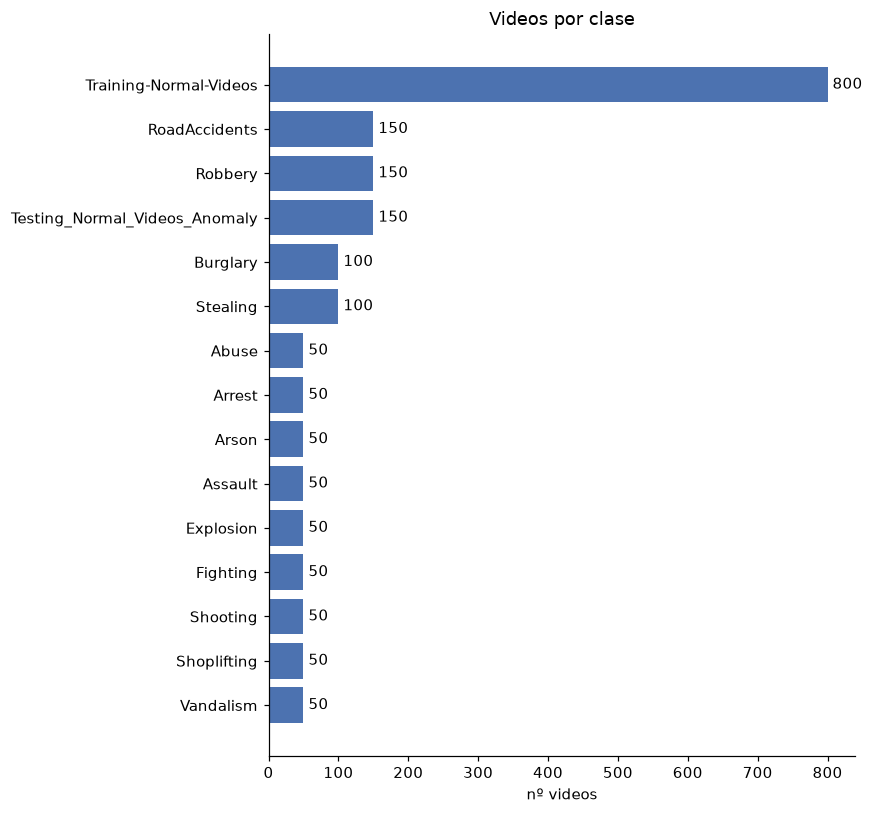

In [4]:
clases = df["clase"].value_counts().rename("videos").to_frame()
clases["pct"] = (clases.videos / clases.videos.sum() * 100).round(1)
display(clases)
print(f"Ratio desbalance (max/min): {clases.videos.max() / clases.videos.min():.1f}")

fig, ax = plt.subplots(figsize=(8, 0.4 * len(clases) + 1.5))
ax.barh(clases.index[::-1], clases.videos[::-1], color="#4C72B0")
for i, val in enumerate(clases.videos[::-1]):
    ax.text(val, i, f" {val}", va="center")
ax.set_title("Videos por clase"); ax.set_xlabel("nº videos")
plt.tight_layout(); plt.savefig(OUT_DIR / "01_clases.png"); plt.show()

## 4. Duración — mínimo, máximo, media, mediana, moda

In [5]:
d = v["duration_s"].dropna()
moda_s = d.round(0).mode().iloc[0]
bins10 = (d // 10 * 10).astype(int)
moda_bin = bins10.mode().iloc[0]
dur = pd.Series({
    "mínimo (s)": d.min(), "máximo (s)": d.max(), "media (s)": d.mean(), "mediana (s)": d.median(),
    "moda (s, redondeada)": moda_s, "moda (intervalo 10 s)": f"{moda_bin}-{moda_bin + 10} s",
    "desv. estándar (s)": d.std(), "p05 (s)": d.quantile(.05), "p95 (s)": d.quantile(.95),
    "total (horas)": d.sum() / 3600,
    "video más corto": v.loc[d.idxmin(), "video"], "video más largo": v.loc[d.idxmax(), "video"],
}).to_frame("valor")
display(dur)
display(v.groupby("clase")["duration_s"].describe().round(2))

,valor
mínimo (s),3.466667
máximo (s),32550.1
media (s),241.592914
mediana (s),71.066667
"moda (s, redondeada)",60.0
moda (intervalo 10 s),30-40 s
desv. estándar (s),1096.435824
p05 (s),15.458333
p95 (s),712.598333
total (horas),127.507371


,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
Abuse,50.0,129.00,156.06,10.00,48.17,89.67,145.93,949.20
Arrest,50.0,198.27,303.58,32.53,60.58,109.25,252.94,2102.00
Arson,50.0,181.27,587.10,12.87,45.06,84.35,138.12,4218.43
Assault,50.0,86.63,96.43,4.57,26.74,59.47,102.16,539.23
Burglary,100.0,157.07,226.04,10.00,43.44,92.25,185.94,1620.80
Explosion,50.0,168.27,663.48,9.20,26.88,55.80,93.54,4730.00
Fighting,50.0,172.60,195.06,26.77,71.69,117.80,205.94,1054.73
RoadAccidents,150.0,57.97,71.48,3.47,22.44,41.73,61.86,602.00
Robbery,150.0,93.91,83.82,9.07,40.39,65.52,116.15,509.27


C:\Users\Usuario\AppData\Local\Temp\ipykernel_45436\1905257309.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([v.loc[v.clase == c, "duration_s"].dropna() for c in orden], vert=False)


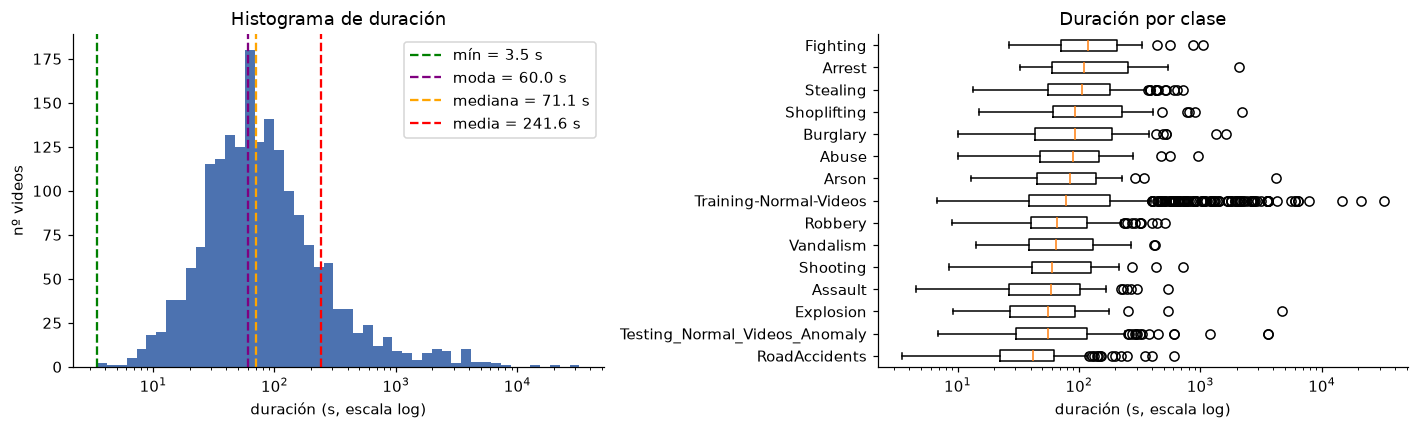

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(d, bins=np.logspace(np.log10(max(d.min(), 0.1)), np.log10(d.max() + 1), 50), color="#4C72B0")
for val, lab, c in [(d.min(), "mín", "green"), (moda_s, "moda", "purple"), (d.median(), "mediana", "orange"), (d.mean(), "media", "red")]:
    axes[0].axvline(val, ls="--", c=c, label=f"{lab} = {val:.1f} s")
axes[0].set_xscale("log"); axes[0].set_xlabel("duración (s, escala log)"); axes[0].set_ylabel("nº videos")
axes[0].set_title("Histograma de duración"); axes[0].legend()
orden = v.groupby("clase")["duration_s"].median().sort_values().index
axes[1].boxplot([v.loc[v.clase == c, "duration_s"].dropna() for c in orden], vert=False)
axes[1].set_yticks(range(1, len(orden) + 1), list(orden))
axes[1].set_xscale("log"); axes[1].set_xlabel("duración (s, escala log)"); axes[1].set_title("Duración por clase")
plt.tight_layout(); plt.savefig(OUT_DIR / "02_duracion.png"); plt.show()

## 5. Resolución, FPS y tamaño — moda

,valor
resolución moda,320x240
orientación,{'horizontal': 1900}
aspect ratio moda,1.333
FPS moda,30.0
FPS rango,25.0 - 30.0
"tamaño moda (MB, redondeado)",7.0
tamaño min / max (MB),0.31 / 8674.01
códec,"{'h264': 1897, 'MJPG': 3}"


resolution,320x240
clase,
Abuse,50
Arrest,50
Arson,50
Assault,50
Burglary,100
Explosion,50
Fighting,50
RoadAccidents,150
Robbery,150


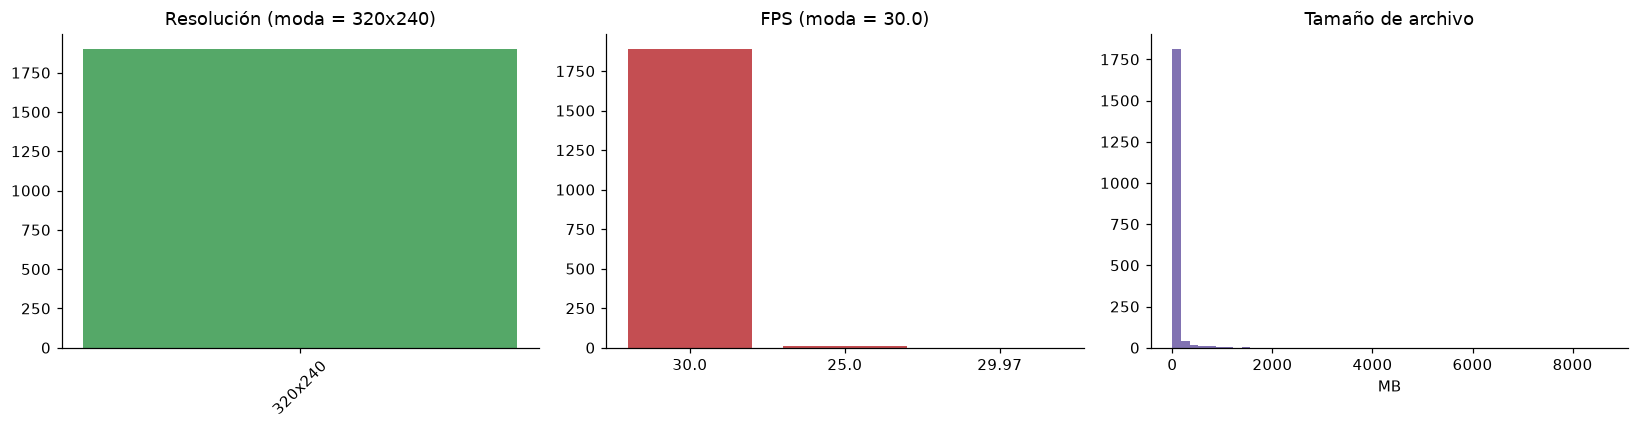

In [7]:
res = pd.Series({
    "resolución moda": v["resolution"].mode().iloc[0],
    "orientación": v["orientation"].value_counts().to_dict(),
    "aspect ratio moda": v["aspect_ratio"].mode().iloc[0],
    "FPS moda": v["fps"].mode().iloc[0],
    "FPS rango": f"{v['fps'].min()} - {v['fps'].max()}",
    "tamaño moda (MB, redondeado)": v["size_mb"].round(0).mode().iloc[0],
    "tamaño min / max (MB)": f"{v['size_mb'].min():.2f} / {v['size_mb'].max():.2f}",
    "códec": v["codec"].value_counts().to_dict(),
}).to_frame("valor")
display(res)
display(pd.crosstab(v["clase"], v["resolution"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rc = v["resolution"].value_counts().head(10)
axes[0].bar(rc.index, rc.values, color="#55A868"); axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title(f"Resolución (moda = {rc.index[0]})")
fc = v["fps"].value_counts().head(10)
axes[1].bar(fc.index.astype(str), fc.values, color="#C44E52"); axes[1].set_title(f"FPS (moda = {fc.index[0]})")
axes[2].hist(v["size_mb"], bins=50, color="#8172B2"); axes[2].set_xlabel("MB"); axes[2].set_title("Tamaño de archivo")
plt.tight_layout(); plt.savefig(OUT_DIR / "03_resolucion_fps_tamano.png"); plt.show()

## 6. Videos monocromáticos y brillo

- **Monocromático**: saturación media HSV < `MONO_SAT_THR` **o** diferencia media entre canales RGB < `MONO_CHAN_THR` (B/N puro e IR nocturno).
- **Oscuro**: brillo medio (luma) < `DARK_THR` = 30. **Muy brillante**: > `BRIGHT_THR` = 200.
- **Borroso**: varianza del Laplaciano < `BLUR_THR`. **Bajo contraste**: desv. estándar de luma < `LOW_CONTRAST_THR`.

In [8]:
calidad = pd.DataFrame({
    "videos": [v.is_monochrome.sum(), v.is_dark.sum(), v.is_bright.sum(), v.is_blurry.sum(), v.is_low_contrast.sum()],
}, index=["monocromáticos", "oscuros (<30)", "muy brillantes (>200)", "borrosos", "bajo contraste"])
calidad["pct"] = (calidad.videos / len(v) * 100).round(1)
display(calidad)
print("Brillo medio global:", round(v.brightness.mean(), 2))
display(v["brightness_cat"].value_counts().to_frame("videos"))

por_clase = v.groupby("clase").agg(n=("video", "count"), brillo_medio=("brightness", "mean"),
    monocromaticos=("is_monochrome", "sum"), oscuros=("is_dark", "sum"), brillantes=("is_bright", "sum")).round(2)
por_clase["%_mono"] = (por_clase.monocromaticos / por_clase.n * 100).round(1)
display(por_clase)

,videos,pct
monocromáticos,232,12.2
oscuros (<30),9,0.5
muy brillantes (>200),0,0.0
borrosos,0,0.0
bajo contraste,2,0.1


Brillo medio global: 90.01


,videos
brightness_cat,
normal,1020
oscuro,863
muy oscuro,9
claro,8
muy brillante,0


,n,brillo_medio,monocromaticos,oscuros,brillantes,%_mono
clase,,,,,,
Abuse,50,88.12,5,0,0,10.0
Arrest,50,80.86,2,0,0,4.0
Arson,50,74.48,20,0,0,40.0
Assault,50,85.81,11,1,0,22.0
Burglary,100,85.88,33,0,0,33.0
Explosion,50,95.68,10,0,0,20.0
Fighting,50,88.83,8,0,0,16.0
RoadAccidents,150,97.59,20,0,0,13.3
Robbery,150,99.26,12,0,0,8.0


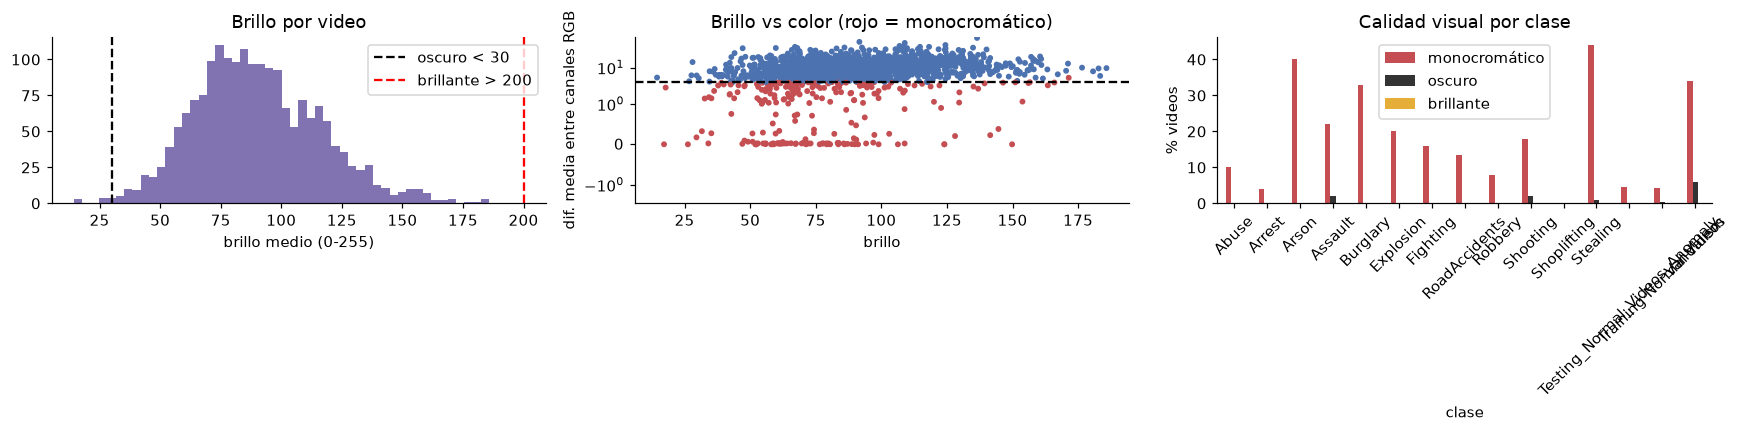

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(v["brightness"], bins=50, color="#8172B2")
axes[0].axvline(DARK_THR, c="k", ls="--", label=f"oscuro < {DARK_THR:.0f}")
axes[0].axvline(BRIGHT_THR, c="r", ls="--", label=f"brillante > {BRIGHT_THR:.0f}")
axes[0].set_xlabel("brillo medio (0-255)"); axes[0].set_title("Brillo por video"); axes[0].legend()

axes[1].scatter(v["brightness"], v["chan_diff"], s=8, c=v["is_monochrome"].map({True: "#C44E52", False: "#4C72B0"}))
axes[1].axhline(MONO_CHAN_THR, c="k", ls="--"); axes[1].set_yscale("symlog", linthresh=1)
axes[1].set_xlabel("brillo"); axes[1].set_ylabel("dif. media entre canales RGB")
axes[1].set_title("Brillo vs color (rojo = monocromático)")

(v.groupby("clase")[["is_monochrome", "is_dark", "is_bright"]].mean() * 100).plot.bar(
    ax=axes[2], color=["#C44E52", "#333333", "#E5AE38"])
axes[2].legend(["monocromático", "oscuro", "brillante"]); axes[2].set_ylabel("% videos")
axes[2].set_title("Calidad visual por clase"); axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(OUT_DIR / "04_brillo_monocromo.png"); plt.show()

In [10]:
cols = ["clase", "video", "brightness", "contrast", "saturation", "chan_diff", "duration_s", "resolution"]
print("Monocromáticos (primeros 20):"); display(v.loc[v.is_monochrome, cols].head(20))
print("10 más oscuros:"); display(v.nsmallest(10, "brightness")[cols])
print("10 más brillantes:"); display(v.nlargest(10, "brightness")[cols])

for flag, nombre in [("is_monochrome", "monocromaticos"), ("is_dark", "oscuros"), ("is_bright", "brillantes")]:
    v.loc[v[flag], cols].to_csv(OUT_DIR / f"lista_{nombre}.csv", index=False)

Monocromáticos (primeros 20):


,clase,video,brightness,contrast,saturation,chan_diff,duration_s,resolution
3,Abuse,Abuse004_x264.mp4,67.836062,76.664729,14.498222,2.230688,559.800000,320x240
4,Abuse,Abuse005_x264.mp4,91.792919,67.430781,16.515104,3.995237,31.633333,320x240
31,Abuse,Abuse032_x264.mp4,52.721270,44.680120,6.789935,1.440310,158.333333,320x240
37,Abuse,Abuse038_x264.mp4,73.581899,53.385602,4.509433,0.707903,29.700000,320x240
45,Abuse,Abuse046_x264.mp4,102.631951,61.256874,13.826796,2.972567,38.633333,320x240
73,Arrest,Arrest024_x264.mp4,53.614771,63.265475,10.649963,1.263031,120.966667,320x240
87,Arrest,Arrest038_x264.mp4,42.549643,52.511030,31.834897,3.538992,73.100000,320x240
103,Arson,Arson005_x264.mp4,69.921932,48.797129,20.978001,3.770540,39.133333,320x240
104,Arson,Arson006_x264.mp4,51.965872,49.422156,0.012164,0.001092,93.833333,320x240
106,Arson,Arson008_x264.mp4,112.646755,57.187606,8.197173,3.224118,40.666667,320x240


10 más oscuros:


,clase,video,brightness,contrast,saturation,chan_diff,duration_s,resolution
818,Stealing,Stealing021_x264.mp4,14.509454,21.012323,99.444722,5.304910,137.366667,320x240
1881,Vandalism,Vandalism032_x264.mp4,17.160754,27.513537,0.006067,0.000352,22.466667,320x240
1690,Training-Normal-Videos,Normal_Videos705_x264.mp4,17.787795,44.748628,42.648706,2.815008,9.466667,320x240
704,Shooting,Shooting005_x264.mp4,26.267417,19.992892,0.000000,0.000000,177.666667,320x240
1858,Vandalism,Vandalism009_x264.mp4,26.761158,35.310640,64.895103,4.192503,44.266667,320x240
1796,Training-Normal-Videos,Normal_Videos824_x264.mp4,27.612580,35.249086,127.884062,6.107962,45.533333,320x240
199,Assault,Assault052_x264.mp4,28.032032,35.085842,162.036810,14.141565,26.300000,320x240
1854,Vandalism,Vandalism005_x264.mp4,29.534000,31.499723,2.289091,0.171442,54.133333,320x240
1849,Training-Normal-Videos,Normal_Videos950_x264.mp4,29.600177,46.142225,85.021882,6.057089,80.400000,320x240
289,Burglary,Burglary090_x264.mp4,30.401731,45.221531,44.316999,5.074216,92.200000,320x240


10 más brillantes:


,clase,video,brightness,contrast,saturation,chan_diff,duration_s,resolution
1557,Training-Normal-Videos,Normal_Videos560_x264.mp4,185.806462,54.021132,22.202623,9.645144,606.700000,320x240
484,RoadAccidents,RoadAccidents086_x264.mp4,183.418536,32.412744,12.261839,5.891744,30.000000,320x240
339,Explosion,Explosion041_x264.mp4,182.813153,36.296366,20.556307,9.452341,91.833333,320x240
329,Explosion,Explosion030_x264.mp4,180.704742,63.366580,19.039871,7.856266,108.133333,320x240
1742,Training-Normal-Videos,Normal_Videos763_x264.mp4,176.503999,66.034249,26.352212,9.936710,120.800000,320x240
719,Shooting,Shooting021_x264.mp4,171.421967,42.868307,11.209792,5.234338,42.500000,320x240
680,Robbery,Robbery131_x264.mp4,171.140304,60.743112,39.355348,12.843425,50.566667,320x240
646,Robbery,Robbery097_x264.mp4,170.435274,61.246899,18.245654,8.156584,117.866667,320x240
429,RoadAccidents,RoadAccidents030_x264.mp4,167.251064,74.015371,15.670586,6.524036,43.000000,320x240
1481,Training-Normal-Videos,Normal_Videos484_x264.mp4,165.954282,71.179367,10.958013,3.873855,1199.100000,320x240


## 7. Inspección visual de muestras

Frame central de 4 videos aleatorios por clase, con su brillo (Y) y duración.

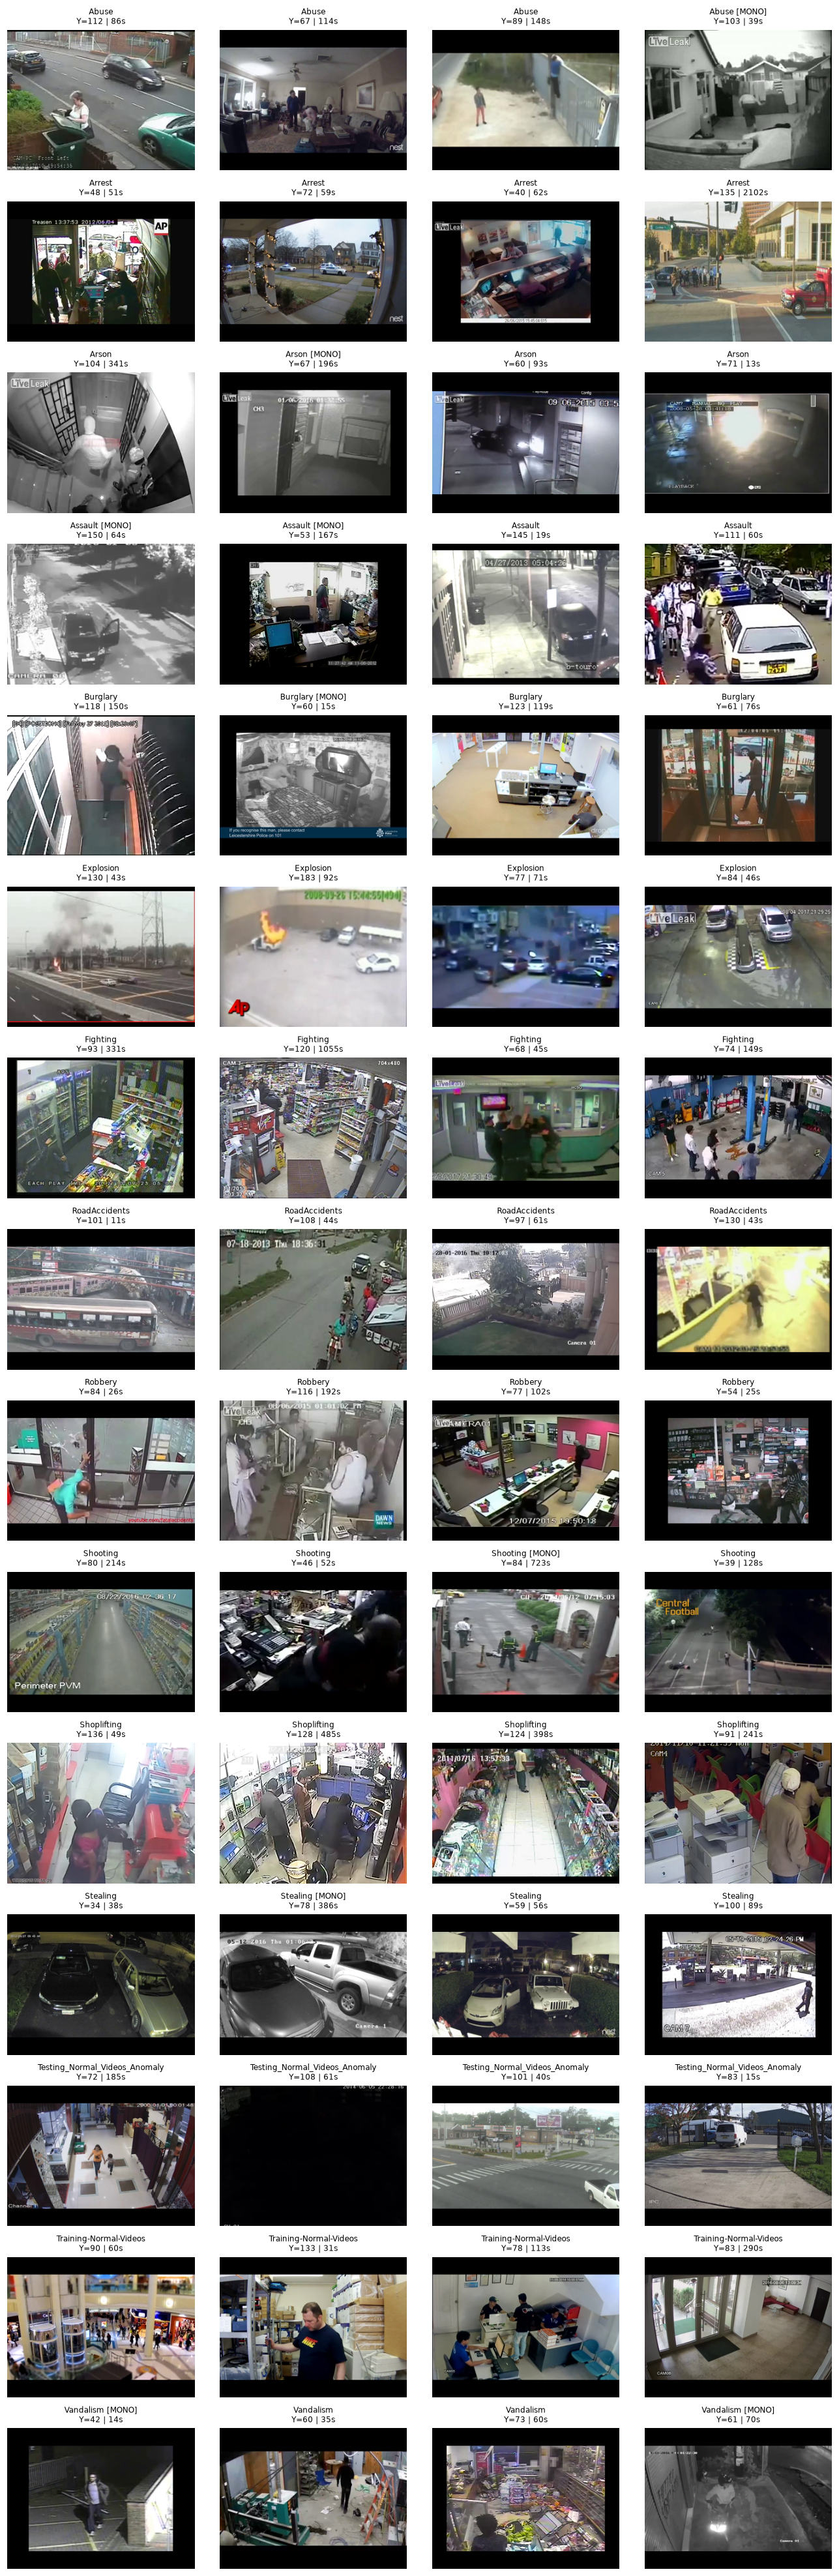

In [11]:
def frame_central(row):
    if row["tipo"] == "frames":
        imgs = sorted(f for f in Path(row["path"]).iterdir() if f.suffix.lower() in IMG_EXT)
        return cv2.imread(str(imgs[len(imgs) // 2]))
    cap = cv2.VideoCapture(row["path"]); cap.set(cv2.CAP_PROP_POS_FRAMES, int(row["n_frames"]) // 2)
    ok_, fr = cap.read(); cap.release()
    return fr if ok_ else None

PER_CLASS = 4
cls = sorted(v["clase"].unique())
fig, axes = plt.subplots(len(cls), PER_CLASS, figsize=(3 * PER_CLASS, 2.4 * len(cls)), squeeze=False)
for r, c in enumerate(cls):
    sub = v[v.clase == c].sample(min(PER_CLASS, (v.clase == c).sum()), random_state=42)
    for k in range(PER_CLASS):
        ax = axes[r][k]; ax.axis("off")
        if k < len(sub):
            row = sub.iloc[k]; fr = frame_central(row)
            if fr is not None:
                ax.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{c}{' [MONO]' if row.is_monochrome else ''}\nY={row.brightness:.0f} | {row.duration_s:.0f}s", fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "05_muestras.png", dpi=100); plt.show()

## 8. Videos corruptos / ilegibles

In [12]:
corruptos = df.loc[df.corrupt, ["clase", "video"]]
corruptos.to_csv(OUT_DIR / "lista_corruptos.csv", index=False)
print(f"{len(corruptos)} corruptos")
corruptos

0 corruptos


,clase,video


## 9. Resumen

In [13]:
resumen = {
    "n_videos": int(len(df)), "n_corruptos": int(df.corrupt.sum()),
    "clases": df["clase"].value_counts().to_dict(),
    "duracion_s": {k: (round(float(x), 2) if isinstance(x, (int, float, np.number)) else x) for k, x in dur["valor"].items()},
    "resolucion_moda": res.loc["resolución moda", "valor"], "fps_moda": float(res.loc["FPS moda", "valor"]),
    "orientacion": res.loc["orientación", "valor"],
    "calidad": calidad["videos"].astype(int).to_dict(),
    "umbrales": dict(DARK_THR=DARK_THR, BRIGHT_THR=BRIGHT_THR, MONO_SAT_THR=MONO_SAT_THR,
                     MONO_CHAN_THR=MONO_CHAN_THR, BLUR_THR=BLUR_THR, LOW_CONTRAST_THR=LOW_CONTRAST_THR),
}
(OUT_DIR / "eda_resumen.json").write_text(json.dumps(resumen, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
resumen

{'n_videos': 1900,
 'n_corruptos': 0,
 'clases': {'Training-Normal-Videos': 800,
  'RoadAccidents': 150,
  'Robbery': 150,
  'Testing_Normal_Videos_Anomaly': 150,
  'Burglary': 100,
  'Stealing': 100,
  'Abuse': 50,
  'Arrest': 50,
  'Arson': 50,
  'Assault': 50,
  'Explosion': 50,
  'Fighting': 50,
  'Shooting': 50,
  'Shoplifting': 50,
  'Vandalism': 50},
 'duracion_s': {'mínimo (s)': 3.47,
  'máximo (s)': 32550.1,
  'media (s)': 241.59,
  'mediana (s)': 71.07,
  'moda (s, redondeada)': 60.0,
  'moda (intervalo 10 s)': '30-40 s',
  'desv. estándar (s)': 1096.44,
  'p05 (s)': 15.46,
  'p95 (s)': 712.6,
  'total (horas)': 127.51,
  'video más corto': 'RoadAccidents027_x264.mp4',
  'video más largo': 'Normal_Videos308_x264.mp4'},
 'resolucion_moda': '320x240',
 'fps_moda': 30.0,
 'orientacion': {'horizontal': 1900},
 'calidad': {'monocromáticos': 232,
  'oscuros (<30)': 9,
  'muy brillantes (>200)': 0,
  'borrosos': 0,
  'bajo contraste': 2},
 'umbrales': {'DARK_THR': 30.0,
  'BRIGHT_TH

## 10. Conclusiones (completar con los resultados)

- **Desbalance de clases**: …
- **Duración**: la moda es … s y la mediana … s; hay videos de … s a … s → se usan L=16 segmentos por video en entrenamiento y ventanas deslizantes en inferencia porque …
- **Resolución**: moda … → todos los frames se redimensionan a 224×224 para los backbones.
- **FPS**: moda … → el muestreo es por segmentos uniformes, independiente del FPS.
- **Monocromáticos**: …% (concentrados en …) → se mantienen y se replican a 3 canales / se analiza su efecto.
- **Brillo**: … videos con brillo < 30 → se excluyen con el filtro de calidad; … videos sobreexpuestos.
- **Corruptos**: … → se eliminan del dataset.